In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, MaxNLocator


# Exploración de datos

In [2]:
df = pd.read_csv('data/raw.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw.csv'

In [ ]:
print("\nMissing Values per Column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])



Missing Values per Column:
Color                        389
Transmisión                   15
Motor                         38
Con cámara de retroceso    13563
dtype: int64


## Marca

Análisis de Marcas:

Cantidad total de marcas únicas: 47

Top 10 marcas más frecuentes:
Marca
Ford          2161
Jeep          2050
Volkswagen    2037
Chevrolet     1750
Renault       1491
Toyota        1260
Peugeot       1250
Nissan        1059
Citroën        721
BMW            672
Name: count, dtype: int64


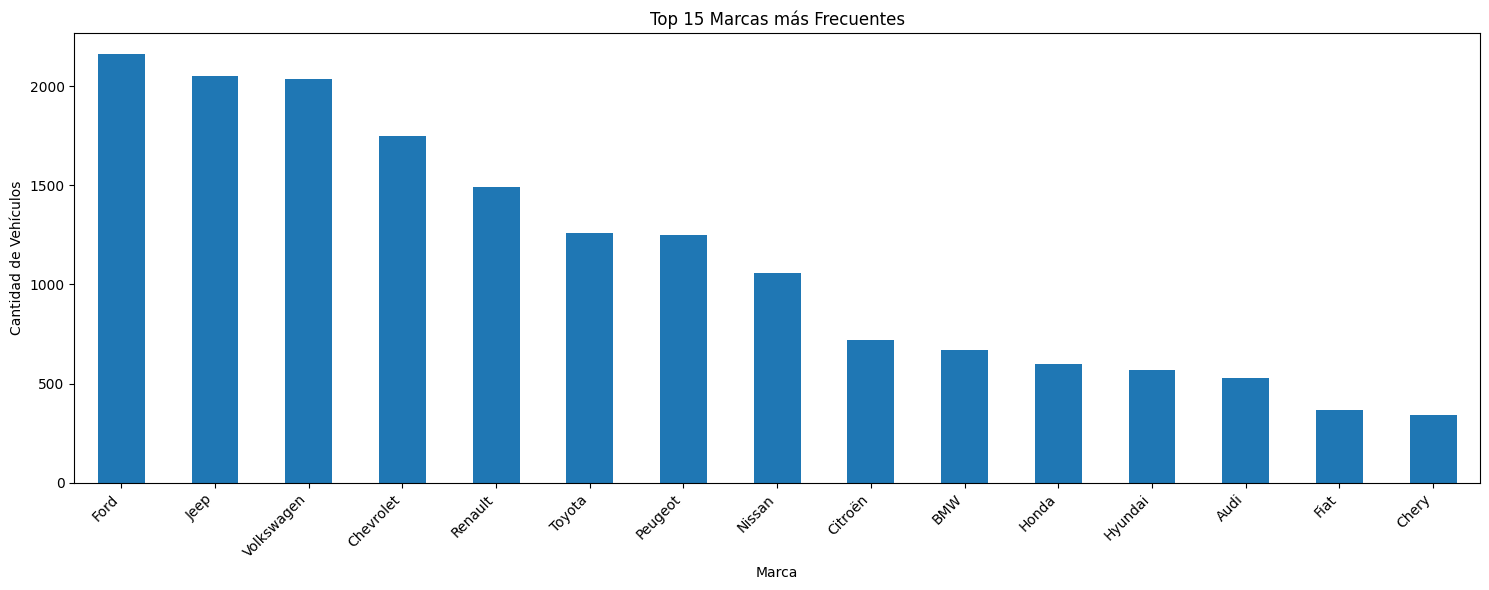

In [4]:
# Count of vehicles by brand
brand_counts = df['Marca'].value_counts()

# Display statistics
print("Análisis de Marcas:")
print(f"\nCantidad total de marcas únicas: {len(brand_counts)}")
print("\nTop 10 marcas más frecuentes:")
print(brand_counts.head(10))

# Plotting
plt.figure(figsize=(15, 6))
brand_counts.head(15).plot(kind='bar')
plt.title('Top 15 Marcas más Frecuentes')
plt.xlabel('Marca')
plt.ylabel('Cantidad de Vehículos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
print("Nombres de todas las marcas:")
print(df['Marca'].unique())

Nombres de todas las marcas:
['Ford' 'Volkswagen' 'Jeep' 'BAIC' 'Kia' 'Hyundai' 'Porsche' 'Peugeot'
 'Fiat' 'Chevrolet' 'Citroën' 'BMW' 'Audi' 'Honda' 'Nissan'
 'Mercedes-Benz' 'Renault' 'Suzuki' 'Toyota' 'D.S.' 'Chery' 'Daihatsu'
 'SsangYong' 'Dodge' 'JAC' 'Land Rover' 'Alfa Romeo' 'Haval' 'Volvo'
 'Lifan' 'Mini' 'D·S' 'Mitsubishi' 'Range Rover' 'Hiunday' 'Jetour' 'GWM'
 'KAIYI' 'Lexus' 'Isuzu' 'Rrenault' 'Subaru' 'Jetur' 'DS AUTOMOBILES'
 'hiunday' 'Jaguar' 'Vol']


## Modelos

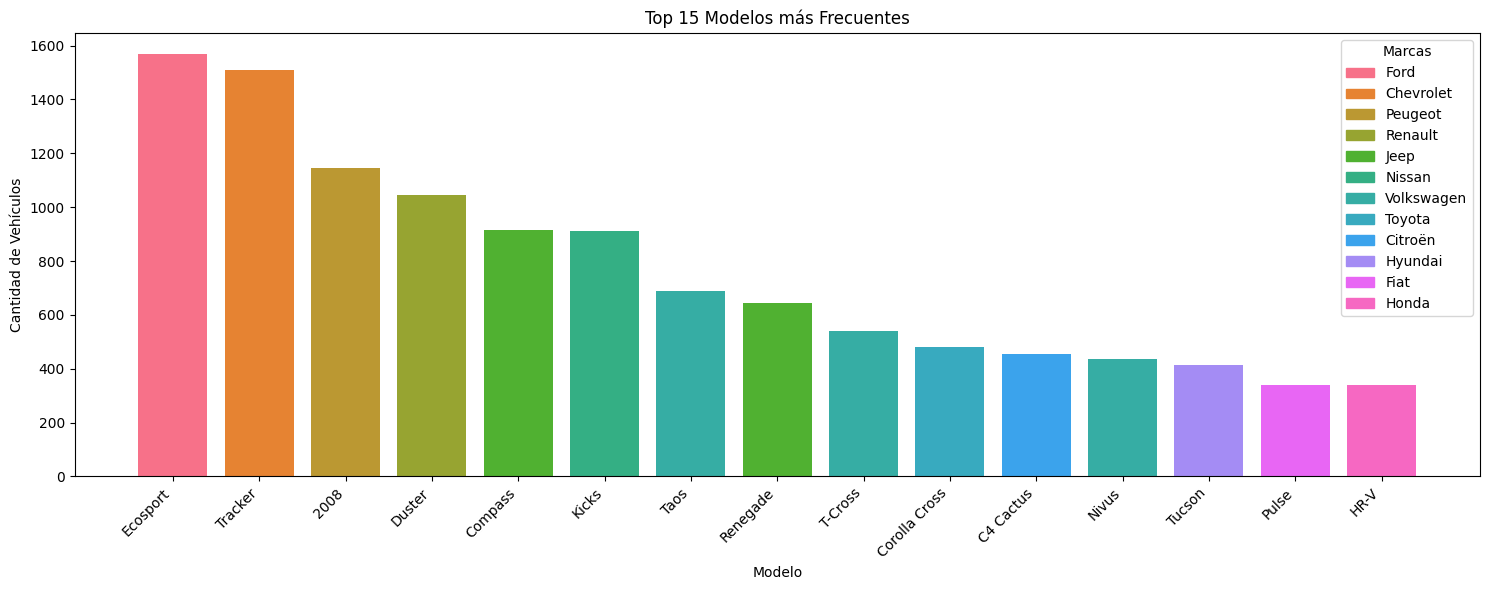


Top 15 modelos más frecuentes (con su marca):
       Modelo      Marca  count
     Ecosport       Ford   1569
      Tracker  Chevrolet   1511
         2008    Peugeot   1144
       Duster    Renault   1047
      Compass       Jeep    916
        Kicks     Nissan    913
         Taos Volkswagen    687
     Renegade       Jeep    643
      T-Cross Volkswagen    539
Corolla Cross     Toyota    482
    C4 Cactus    Citroën    453
        Nivus Volkswagen    436
       Tucson    Hyundai    415
        Pulse       Fiat    341
         HR-V      Honda    339


In [6]:
# Count of vehicles by model and brand
model_brand_counts = df.groupby(['Modelo', 'Marca']).size().reset_index(name='count')
model_counts = model_brand_counts.sort_values('count', ascending=False)

# Get top 15 models
top_15_models = model_counts.head(15)

# Create a color map for brands
unique_brands = top_15_models['Marca'].unique()
color_palette = sns.color_palette("husl", len(unique_brands))
brand_colors = dict(zip(unique_brands, color_palette))

# Plotting
plt.figure(figsize=(15, 6))

# Create bars with colors based on brand
bars = plt.bar(range(len(top_15_models)), top_15_models['count'], 
               color=[brand_colors[marca] for marca in top_15_models['Marca']])

# Create legend
legend_elements = [plt.Rectangle((0,0),1,1, color=color, label=brand) 
                  for brand, color in brand_colors.items()]
plt.legend(handles=legend_elements, title="Marcas", loc='upper right')

# Customize the plot
plt.title('Top 15 Modelos más Frecuentes')
plt.xlabel('Modelo')
plt.ylabel('Cantidad de Vehículos')

# Set x-axis labels (only models, as brands are shown by color)
plt.xticks(range(len(top_15_models)), top_15_models['Modelo'], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display statistics
print("\nTop 15 modelos más frecuentes (con su marca):")
print(top_15_models[['Modelo', 'Marca', 'count']].to_string(index=False))

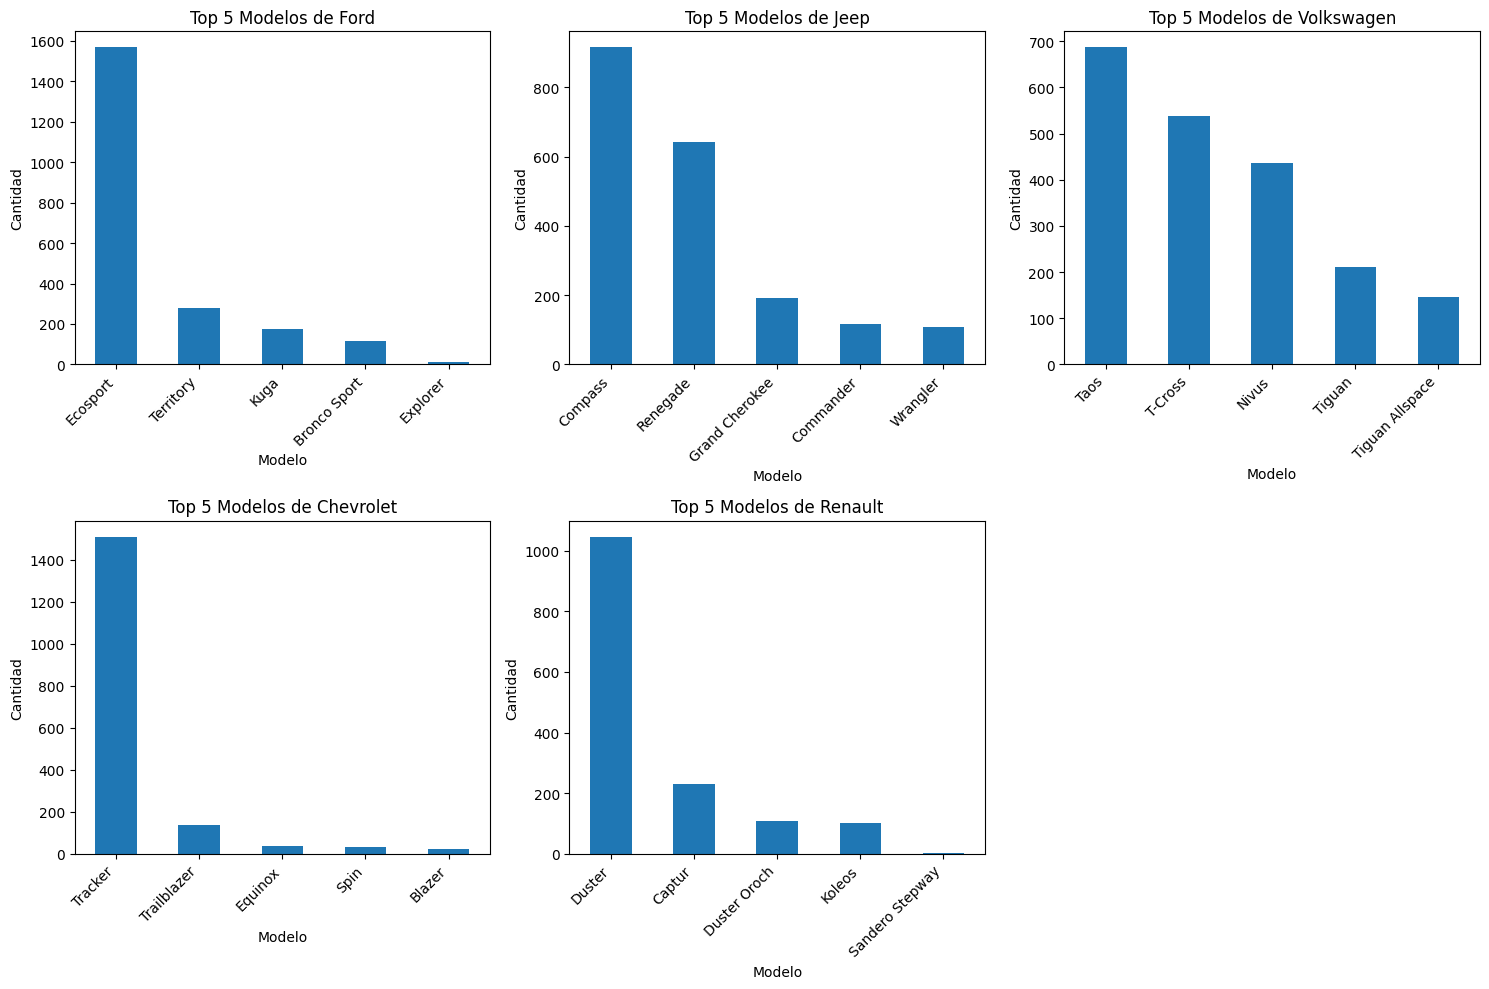

In [7]:
top_5_marcas = brand_counts.head(5).index

plt.figure(figsize=(15, 10))
for i, marca in enumerate(top_5_marcas, 1):
    plt.subplot(2, 3, i)
    df[df['Marca'] == marca]['Modelo'].value_counts().head(5).plot(kind='bar')
    plt.title(f'Top 5 Modelos de {marca}')
    plt.xlabel('Modelo')
    plt.ylabel('Cantidad')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

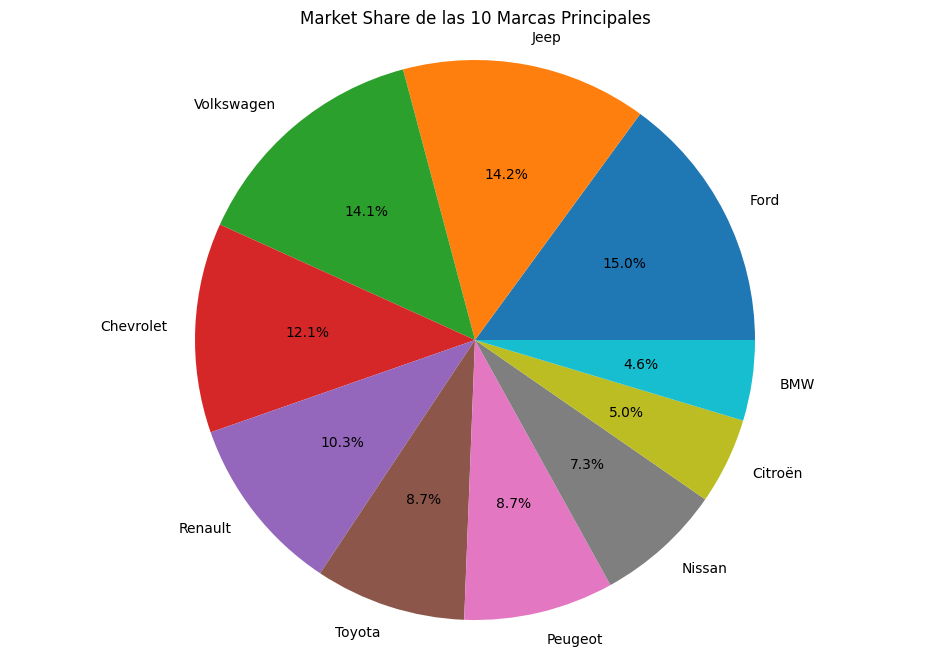

In [8]:
# Calculate market share by brand
market_share = (df['Marca'].value_counts() / len(df) * 100).round(2)

# Create a pie chart for top 10 brands
plt.figure(figsize=(12, 8))
plt.pie(market_share.head(10), labels=market_share.head(10).index, autopct='%1.1f%%')
plt.title('Market Share de las 10 Marcas Principales')
plt.axis('equal')
plt.show()

## Versión

Cantidad de modelos con más de una versión: 129

Top 10 modelos con más versiones:
          Marca     Modelo  N_versiones
50         Ford   Ecosport          110
31    Chevrolet    Tracker           98
73         Jeep    Compass           81
122     Renault     Duster           77
113     Peugeot       2008           53
145  Volkswagen     Tiguan           53
137      Toyota  Hilux SW4           53
76         Jeep   Renegade           51
67      Hyundai     Tucson           51
140      Toyota        SW4           46


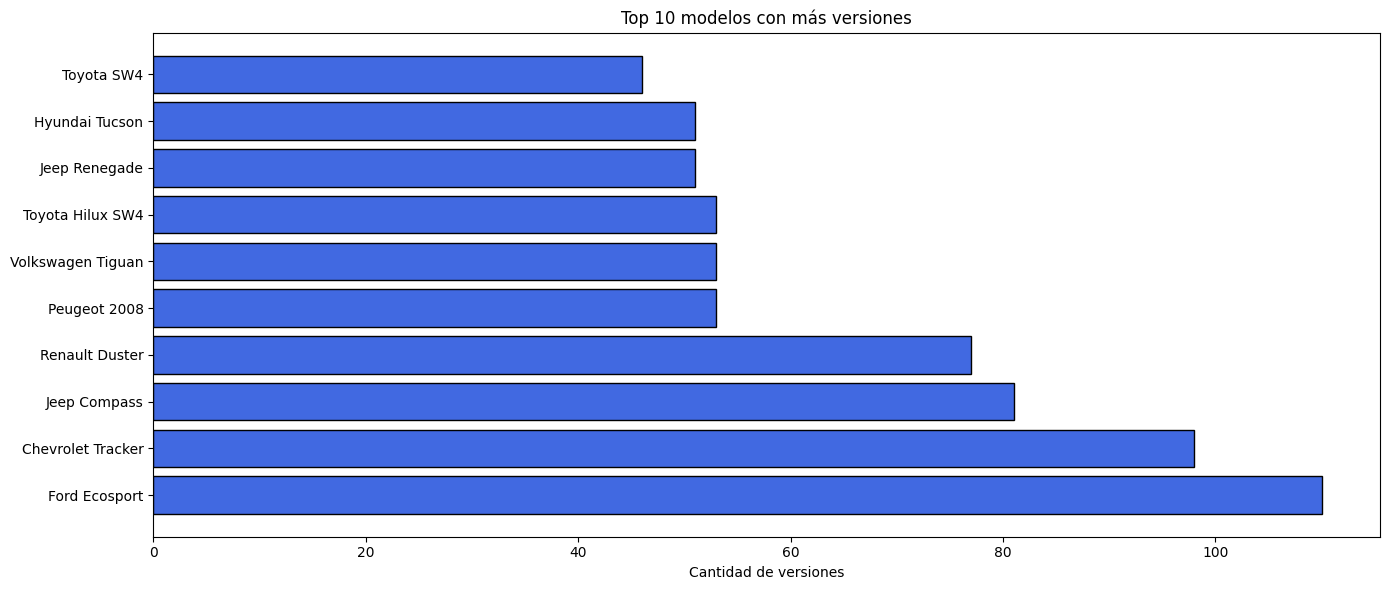

In [9]:
version_counts = df.groupby(['Marca', 'Modelo', 'Versión']).size().reset_index(name='Cantidad')

model_version_counts = version_counts.groupby(['Marca', 'Modelo']).size().reset_index(name='N_versiones')
more_than_one_version = model_version_counts[model_version_counts['N_versiones'] > 1]
print(f"Cantidad de modelos con más de una versión: {len(more_than_one_version)}")

# Top 10 modelos con más versiones
top_models_versions = model_version_counts.sort_values('N_versiones', ascending=False).head(10)
print("\nTop 10 modelos con más versiones:")
print(top_models_versions)

# Visualización: Top 10 modelos con más versiones
plt.figure(figsize=(14, 6))
plt.barh(
    top_models_versions['Marca'] + ' ' + top_models_versions['Modelo'],
    top_models_versions['N_versiones'],
    color='royalblue',
    edgecolor='black'
)
plt.xlabel('Cantidad de versiones')
plt.title('Top 10 modelos con más versiones')
plt.tight_layout()
plt.show()



In [10]:
marca_ejemplo = 'Volkswagen'
modelo_ejemplo = 'Taos'

print(f"\nVersiones para {marca_ejemplo} {modelo_ejemplo}:")
print(version_counts[(version_counts['Marca'] == marca_ejemplo) & (version_counts['Modelo'] == modelo_ejemplo)])

# Save filtered versions to CSV
filtered_versions = version_counts[(version_counts['Marca'] == marca_ejemplo) & (version_counts['Modelo'] == modelo_ejemplo)]
filtered_versions.to_csv(f"versiones_{marca_ejemplo}_{modelo_ejemplo}.csv", index=False)


Versiones para Volkswagen Taos:
           Marca Modelo                                 Versión  Cantidad
2002  Volkswagen   Taos       1.4 250 TSI COMFORTLINE AUTO MY24         1
2003  Volkswagen   Taos   1.4 250 TSI COMFORTLINE TIPTRONIC L23         1
2004  Volkswagen   Taos          1.4 250 TSI HERO TIPTRONIC L21         1
2005  Volkswagen   Taos  1.4 250 TSI HIGHLINE BI TONO AUTO MY24         1
2006  Volkswagen   Taos      1.4 250 TSI HIGHLINE TIPTRONIC L21         1
2007  Volkswagen   Taos                 1.4 250 Tsi Comfortline       261
2008  Volkswagen   Taos       1.4 250 Tsi Comfortline Tiptronic        29
2009  Volkswagen   Taos  1.4 250 Tsi Comfortline Tiptronic L/24         1
2010  Volkswagen   Taos                        1.4 250 Tsi Hero        15
2011  Volkswagen   Taos                    1.4 250 Tsi Highline       255
2012  Volkswagen   Taos            1.4 250 Tsi Highline Bi Tono        58
2013  Volkswagen   Taos  1.4 250 Tsi Highline Bi Tono Tiptronic         7
2014 

## Motor

In [11]:
unique_engines = df['Motor'].unique()

print(f"Tipos de motor: {len(unique_engines)}")

numeric_engines = [engine for engine in unique_engines if isinstance(engine, str) and engine.replace('.', '', 1).isdigit()]
print(f"Cantidad de tipos de motor numéricos (ejemplo: 1.6): {len(numeric_engines)}")

def is_turbo(engine):
    if not isinstance(engine, str):
        return False
    # Busca ' T', 'T ', ' Turbo', 'Turbo', ' TSI', 'TSI', etc., pero no solo una 't' suelta
    return bool(re.search(r'(?:\d[\.,]?\d?\s*[tT]|Turbo|TSI|TFSI|TURBO)', engine))

turbo_engines = [engine for engine in unique_engines if is_turbo(engine)]
print(f"Cantidad de tipos de motor con turbo (ejemplo: 1.0 T, 2.0T, 1.0 Turbo): {len(turbo_engines)}")
print("Ejemplos:", turbo_engines[:10])

Tipos de motor: 273
Cantidad de tipos de motor numéricos (ejemplo: 1.6): 53
Cantidad de tipos de motor con turbo (ejemplo: 1.0 T, 2.0T, 1.0 Turbo): 112
Ejemplos: ['2.0 L 230 CV  350 TSI', '1.5 TURBO', '1.2 TURBO', 'TURBOALIMENTADO', 'TURBO DIESEL INYECCION', '1.3T', '1.5t', '1.4 TFSI', '2.0 TDI 140CV', '1.3 TURBO']


# Transmisión

In [1]:
transmission_counts = df['Transmisión'].value_counts()
print("\nCantidad de transmisiones únicas:", len(transmission_counts), "\n")

with pd.option_context('display.max_rows', None):
    print(transmission_counts)

NameError: name 'df' is not defined

## Color

In [12]:
color_counts = df['Color'].value_counts()
print("\nCantidad de colores únicos:", len(color_counts), "\n")

with pd.option_context('display.max_rows', None):
    print(color_counts)


Cantidad de colores únicos: 70 

Color
Gris                             5468
Blanco                           4809
Negro                            2825
Plateado                         1427
Azul                             1121
Rojo                             1118
Marrón                            253
Dorado                            190
Verde                             135
Beige                             125
Celeste                            93
Naranja                            73
Gris oscuro                        43
Violeta                            33
Bordó                              29
Amarillo                           24
Rosa                                8
Plata                               7
Otro                                6
Acero                               4
Blanca                              4
BLANCA                              3
Café                                3
Gris plata                          3
Negra                               3
MINERALWEI

## Kilometraje

In [13]:
# Filtro

kilometers = (
    df['Kilómetros']
    .astype(str)
    .str.lower()
    .str.replace('km', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace('', np.nan)
    .astype(float)
)

df['Kilómetros'] = kilometers

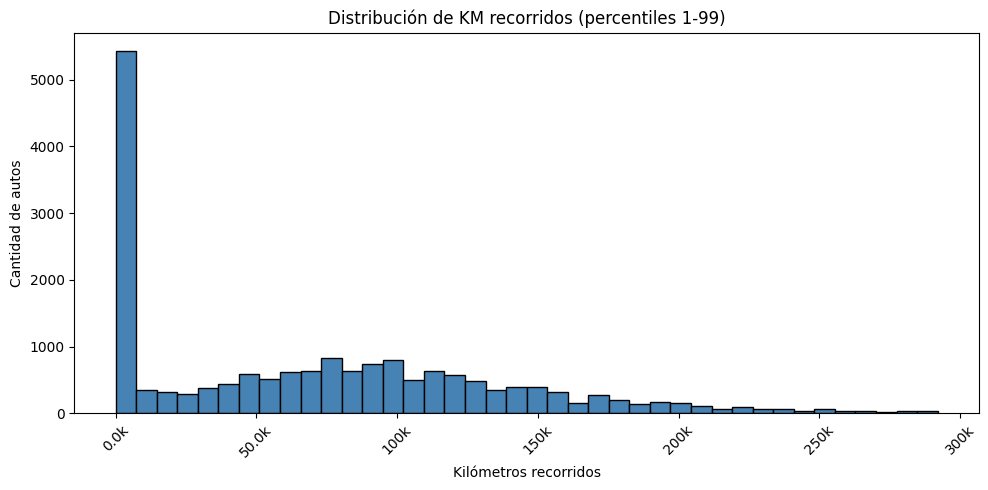

In [14]:
p1  = np.percentile(kilometers, 1)
p99 = np.percentile(kilometers, 99)
filtered_km = kilometers[(kilometers >= p1) & (kilometers <= p99)]

# --- histograma ---
plt.figure(figsize=(10, 5))
plt.hist(filtered_km, bins=40, color="steelblue", edgecolor="black")
plt.xlabel("Kilómetros recorridos")
plt.ylabel("Cantidad de autos")
plt.title("Distribución de KM recorridos (percentiles 1-99)")

# --- ticks cada 50 000 km (cambiá step_km si querés 10 k, 25 k, etc.) ---
step_km = 50_000           # 50 k
xmin, xmax = 0, filtered_km.max()
ticks = np.arange(xmin, xmax + step_km, step_km)
plt.xticks(ticks)

# --- formateo: un decimal cuando hace falta ---
def km_formatter(x, pos):
    val_k = x / 1_000      # pasamos a miles
    if val_k < 100:        # < 100k  → un decimal
        return f"{val_k:,.1f}k".replace(",", ".")
    else:                  # ≥ 100k  → entero
        return f"{val_k:,.0f}k".replace(",", ".")

plt.gca().xaxis.set_major_formatter(FuncFormatter(km_formatter))
plt.gca().tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


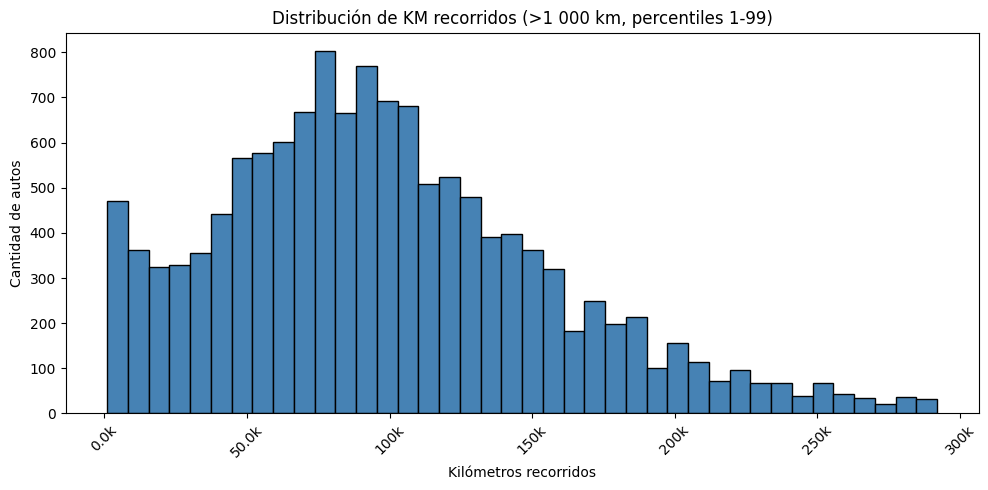

In [15]:
used_km = filtered_km[filtered_km > 1_000]

plt.figure(figsize=(10, 5))
plt.hist(used_km, bins=40, color="steelblue", edgecolor="black")
plt.xlabel("Kilómetros recorridos")
plt.ylabel("Cantidad de autos")
plt.title("Distribución de KM recorridos (>1 000 km, percentiles 1-99)")

# mismo eje X
step_km = 50_000
ticks = np.arange(0, used_km.max() + step_km, step_km)
plt.xticks(ticks)

def km_formatter(x, pos):
    val_k = x / 1_000
    return f"{val_k:,.1f}k".replace(",", ".") if val_k < 100 else f"{val_k:,.0f}k".replace(",", ".")

plt.gca().xaxis.set_major_formatter(FuncFormatter(km_formatter))
plt.gca().tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## Año

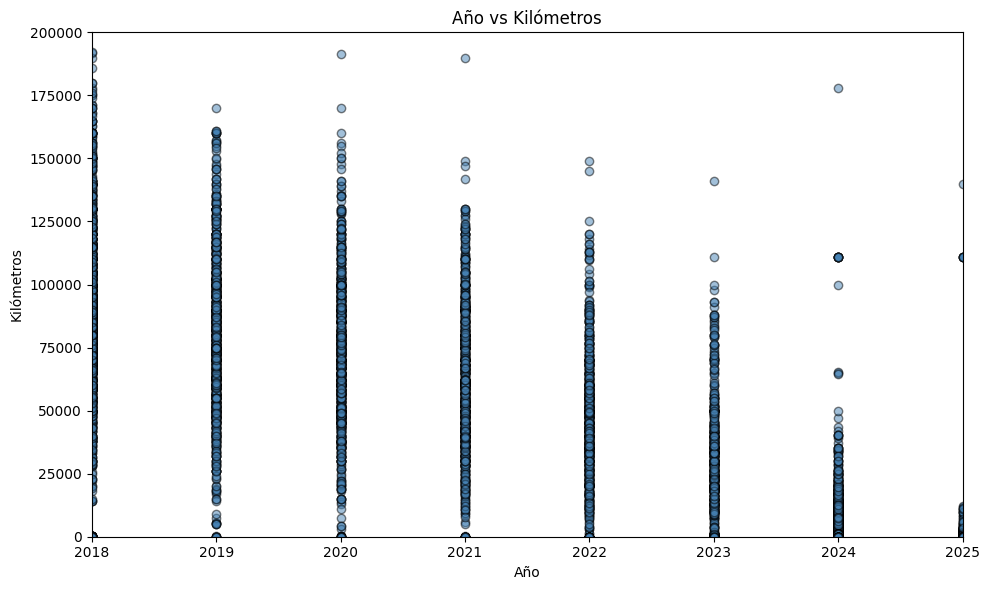

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Año'], df['Kilómetros'], alpha=0.5, color='steelblue', edgecolor='k')
plt.xlabel('Año')
plt.xlim(2018, 2025)  # Ajustar el rango de años según los datos
plt.ylim(0, 200000)  # Ajustar el límite superior de kilómetros
plt.ylabel('Kilómetros')
plt.title('Año vs Kilómetros')
plt.tight_layout()
plt.show()

## Precio

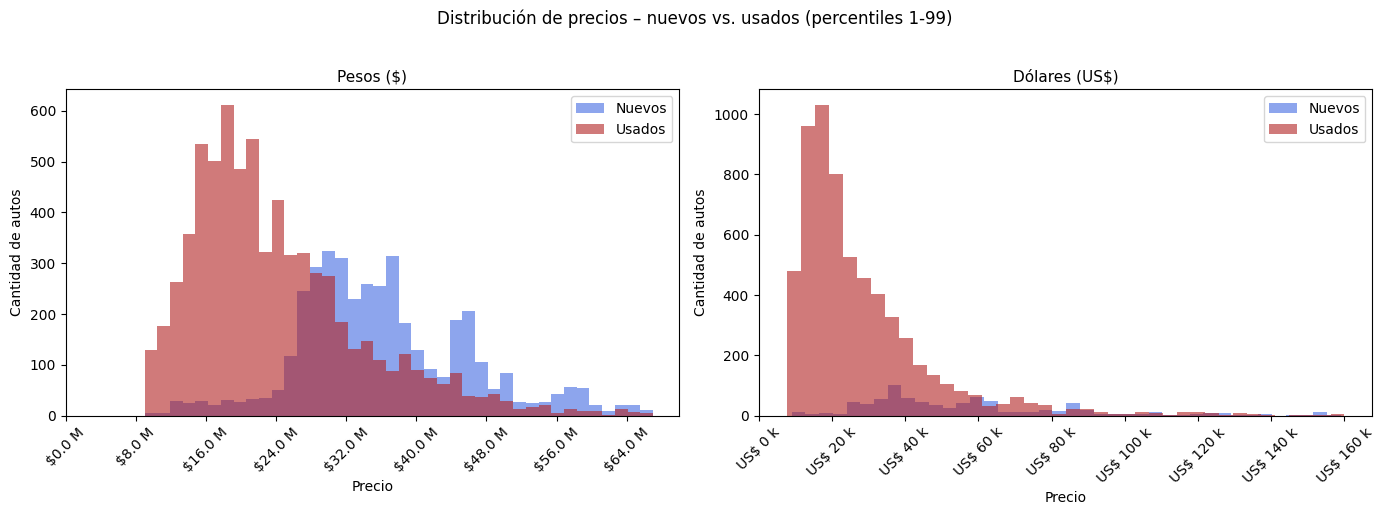

In [17]:
mask_pesos = df['Moneda'] == '$'
mask_usd   = df['Moneda'].str.contains('US')
mask_new   = df['Kilómetros'] <= 1_000
mask_used  = df['Kilómetros'] > 1_000



def plot_overlay(ax, data_new, data_used, title, step, formatter):
    all_prices = pd.concat([data_new, data_used])
    p1, p99 = np.percentile(all_prices, [1, 99])

    new_filt  = data_new[(data_new  >= p1) & (data_new  <= p99)]
    used_filt = data_used[(data_used >= p1) & (data_used <= p99)]

    ax.hist(new_filt,  bins=40, color="royalblue", alpha=0.6, label="Nuevos")
    ax.hist(used_filt, bins=40, color="firebrick", alpha=0.6, label="Usados")

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Precio")
    ax.set_ylabel("Cantidad de autos")
    ax.legend()

    ticks = np.arange(0, p99 + step, step)
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(formatter)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
    ax.tick_params(axis="x", rotation=45)



fmt_pesos = FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f} M")
fmt_usd   = FuncFormatter(lambda x, pos: f"US$ {x/1_000:.0f} k")


fig, (ax_pesos, ax_usd) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribución de precios – nuevos vs. usados (percentiles 1-99)", y=1.02)

plot_overlay(
    ax_pesos,
    df.loc[mask_pesos & mask_new,  'Precio'],
    df.loc[mask_pesos & mask_used, 'Precio'],
    "Pesos ($)",
    step=5_000_000,
    formatter=fmt_pesos
)

plot_overlay(
    ax_usd,
    df.loc[mask_usd & mask_new,  'Precio'],
    df.loc[mask_usd & mask_used, 'Precio'],
    "Dólares (US$)",
    step=5_000,
    formatter=fmt_usd
)

plt.tight_layout()
plt.show()

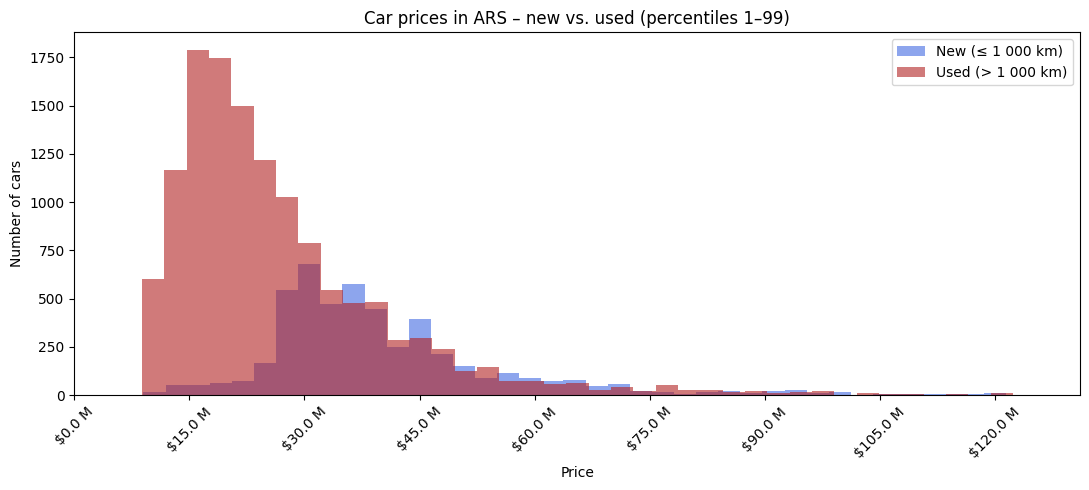

In [18]:
exchange_rate = 1100

price_ars = df["Precio"].copy()
price_ars[df["Moneda"].str.contains("US")] *= exchange_rate

new_mask  = df["Kilómetros"] <= 1_000
used_mask = df["Kilómetros"] >  1_000

p_low, p_high = np.percentile(price_ars, [1, 99])

new_prices  = price_ars[new_mask]
used_prices = price_ars[used_mask]

new_filtered  = new_prices[(new_prices  >= p_low) & (new_prices  <= p_high)]
used_filtered = used_prices[(used_prices >= p_low) & (used_prices <= p_high)]

fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(new_filtered,  bins=40, color="royalblue", alpha=0.6, label="New (≤ 1 000 km)")
ax.hist(used_filtered, bins=40, color="firebrick", alpha=0.6, label="Used (> 1 000 km)")

ax.set_title("Car prices in ARS – new vs. used (percentiles 1–99)")
ax.set_xlabel("Price")
ax.set_ylabel("Number of cars")
ax.legend()

# X-axis ticks and formatting
tick_step = 5_000_000                                  # 5 million ARS
ticks = np.arange(0, p_high + tick_step, tick_step)
ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f} M"))
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

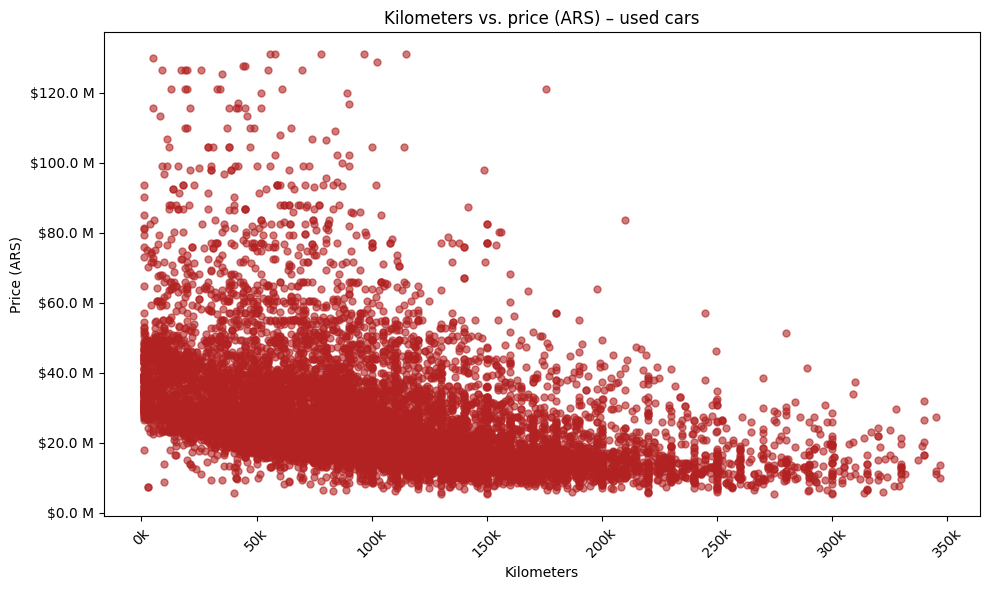

In [19]:
km_low, km_high       = np.percentile(kilometers[used_mask], [.1, 99.5])
price_low, price_high = np.percentile(price_ars[used_mask], [.1, 99.5])
in_range = (kilometers.between(km_low, km_high) &
            price_ars.between(price_low, price_high) &
            used_mask)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(kilometers[in_range],
           price_ars[in_range],
           s=25, color="firebrick", alpha=0.6)

ax.set_title("Kilometers vs. price (ARS) – used cars")
ax.set_xlabel("Kilometers")
ax.set_ylabel("Price (ARS)")

# axis formatters
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000:.0f}k"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"${y/1_000_000:.1f} M"))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


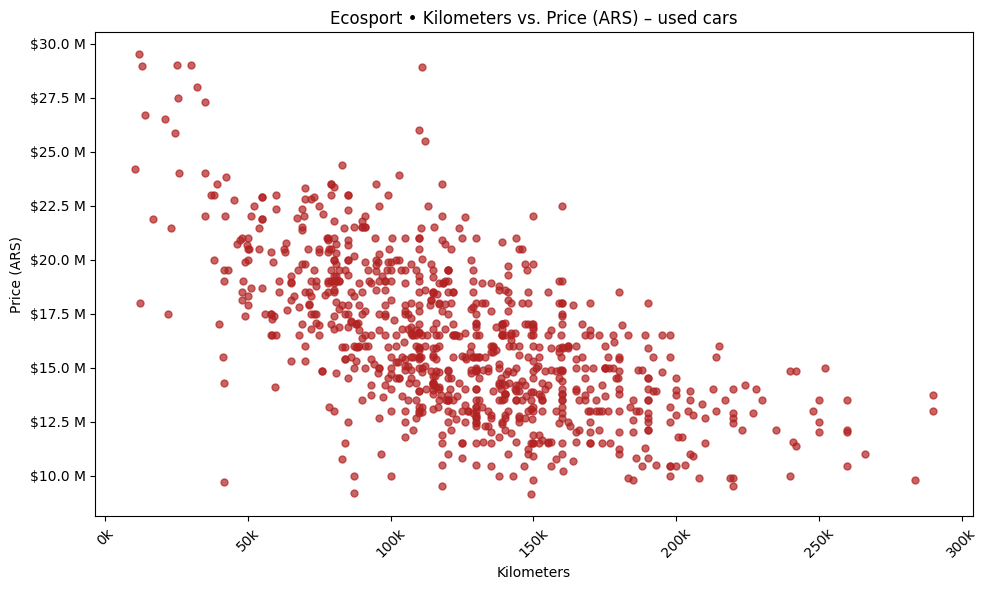

In [20]:
# ------------------------------------------------------------------
# 1) seleccionar SOLO dusters usados
# ------------------------------------------------------------------
model_mask = df["Modelo"].str.lower() == "duster"
selection  = used_mask & model_mask            # (>1 000 km  y  modelo Ecosport)

km_sel    = kilometers[selection]
price_sel = price_ars[selection]

# ------------------------------------------------------------------
# 2) (opcional) recorte 1–99 % para limpiar outliers extremos
# ------------------------------------------------------------------
km_low, km_high       = np.percentile(km_sel,   [1, 99])
price_low, price_high = np.percentile(price_sel, [1, 99])

in_range = (
    km_sel.between(km_low, km_high) &
    price_sel.between(price_low, price_high)
)

# ------------------------------------------------------------------
# 3) scatter plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    km_sel[in_range],
    price_sel[in_range],
    s=25,
    color="firebrick",
    alpha=0.7
)

ax.set_title("Ecosport • Kilometers vs. Price (ARS) – used cars")
ax.set_xlabel("Kilometers")
ax.set_ylabel("Price (ARS)")

# formato de ejes
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000:.0f}k"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"${y/1_000_000:.1f} M"))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


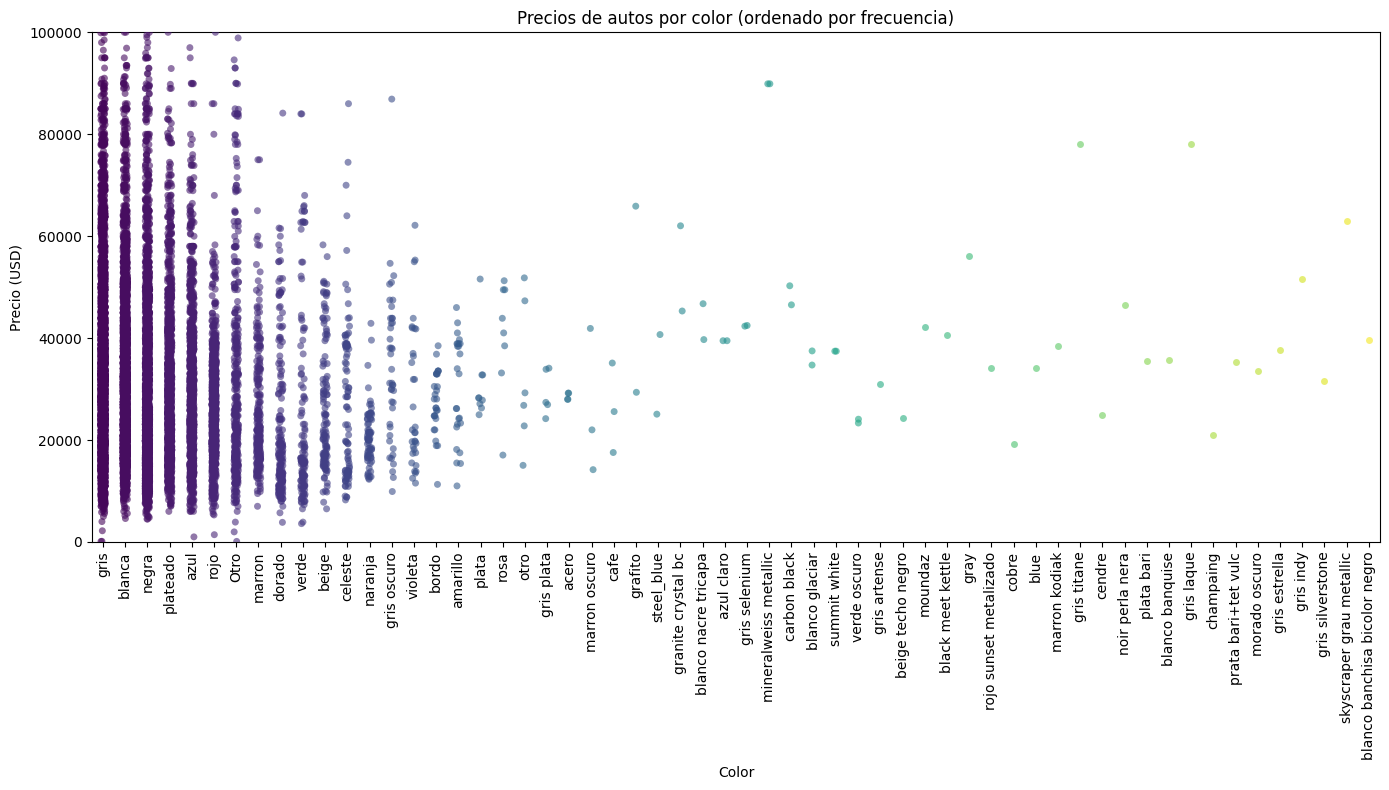

In [59]:

import unicodedata
import difflib

# 🧼 Normalizar texto
def normalizar(texto):
    texto = texto.lower().strip()
    texto = ''.join(c for c in unicodedata.normalize('NFKD', texto) if not unicodedata.combining(c))
    return texto

# 🔄 Agrupar colores automáticamente
colores_norm = [normalizar(c) for c in df['Color'].dropna().unique()]
grupos = {}

for color in colores_norm:
    match = difflib.get_close_matches(color, grupos.keys(), n=1, cutoff=0.8)
    if match:
        grupos[match[0]].append(color)
    else:
        grupos[color] = [color]

mapa_color = {}
for clave, variantes in grupos.items():
    nombre_grupo = max(variantes, key=variantes.count)
    for v in variantes:
        mapa_color[v] = nombre_grupo

def limpiar_color_auto(color):
    if pd.isnull(color):
        return 'Otro'
    color_norm = normalizar(color)
    return mapa_color.get(color_norm, 'Otro')

df['Color_limpio'] = df['Color'].apply(limpiar_color_auto)

# 💱 Convertir precio a USD
conversion = {'US$': 1.0, '$': 0.0011}
df['Precio_USD'] = df.apply(lambda row: row['Precio'] * conversion.get(row['Moneda'], 1.0), axis=1)

# 📊 Ordenar los colores por frecuencia
frecuencia_colores = df['Color_limpio'].value_counts()
orden_colores = frecuencia_colores.index.tolist()

# Convertir la columna en una categoría ordenada
df['Color_limpio'] = pd.Categorical(df['Color_limpio'], categories=orden_colores, ordered=True)

# 📈 Gráfico scatter con colores ordenados
plt.figure(figsize=(14, 8))
sns.stripplot(data=df.sort_values('Color_limpio'),
              x='Color_limpio', y='Precio_USD',
              hue='Color_limpio', dodge=False, legend=False,
              jitter=True, alpha=0.6, palette='viridis')
plt.ylabel('Precio (USD)')
plt.xlabel('Color')
plt.ylim(0, 1e5)
plt.title('Precios de autos por color (ordenado por frecuencia)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()